# TESI DI LAUREA 
## Cavallari Anna matr.1099291




## EDA & Preprocessing 

Questo notebook illustra un flusso completo di **Exploratory Data Analysis (EDA)** e **preprocessing** sul dataset COMPAS.

### Struttura del notebook
1. Setup & caricamento dati
2. Ispezione iniziale
3. Analisi valori mancanti
4. Analisi distribuzione features numeriche
5. Analisi features categoriche
6. Analisi correlazioni
7. Rilevamento outlier
8. Preprocessing
9. Dataset finale

## 1. Setup & Caricamento Dati

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Impostazioni visualizzazione
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


DOWNLOAD DATASET COMPAS

In [2]:
import os
import pandas as pd

file_path = "ds/compas-scores-two-years (1).csv"   # oppure il path completo

df = pd.read_csv(file_path)

print(f"Dataset caricato: {df.shape[0]:,} righe × {df.shape[1]} colonne")
df.head()

Dataset caricato: 7,214 righe × 53 colonne


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [3]:
df.shape

(7214, 53)

In [4]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')

### esplorazione del dataset iniziale

In [43]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,7192.000,7214.000,2316.000,0.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000
mean,5501.256,34.818,0.067,4.510,0.091,0.109,3.472,3.305,57.731,0.481,20.269,NaN,0.114,4.510,3.692,3.472,11.465,553.437,0.383,0.451
std,3175.707,11.889,0.474,2.856,0.485,0.502,4.883,75.810,329.740,0.500,74.872,NaN,0.317,2.856,2.510,4.883,46.955,399.021,0.486,0.498
min,1.000,18.000,0.000,1.000,0.000,0.000,0.000,-414.000,0.000,0.000,-1.000,NaN,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000
25%,2735.250,25.000,0.000,2.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,NaN,0.000,2.000,1.000,0.000,0.000,148.250,0.000,0.000
50%,5509.500,31.000,0.000,4.000,0.000,0.000,2.000,-1.000,1.000,0.000,0.000,NaN,0.000,4.000,3.000,2.000,0.000,530.500,0.000,0.000
75%,8246.500,42.000,0.000,7.000,0.000,0.000,5.000,0.000,2.000,1.000,1.000,NaN,0.000,7.000,5.000,5.000,1.000,914.000,1.000,1.000
max,11001.000,96.000,20.000,10.000,13.000,17.000,38.000,1057.000,9485.000,1.000,993.000,NaN,1.000,10.000,10.000,38.000,937.000,1186.000,1.000,1.000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

In [6]:
df.describe(include="all")

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214,7214,7214,7214,7214,7214,7214.000,7214,7214,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,6907,6907,7192,6055,1137,7192.000,7214,7185,7214.000,3471,3471,2316.000,3471,3413,2316,2316,0.000,7214.000,819,819,819,819,7214,7214.000,7214,7214,7214,7214.000,7214,7214,6978,6978,7214.000,7214.000,7214.000,7214.000,7214.000
unique,NaN,7158,2800,3950,690,2,5452,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN,6907,6880,7192,927,580,NaN,2,437,NaN,3471,10,NaN,1075,340,972,938,NaN,NaN,819,9,570,83,1,NaN,3,690,1,NaN,3,690,1156,1169,NaN,NaN,NaN,NaN,NaN
top,NaN,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,NaN,25 - 45,African-American,NaN,NaN,NaN,NaN,NaN,NaN,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,NaN,F,Battery,NaN,13009779CF10A,(M1),NaN,2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,NaN,NaN,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,NaN,Low,2013-02-20,Risk of Violence,NaN,Low,2013-02-20,2014-01-22,2020-01-01,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,149,83,32,5819,5,NaN,4109,3696,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,26,9,NaN,4666,1156,NaN,1,1201,NaN,12,258,9,9,NaN,NaN,1,344,6,329,7214,NaN,3897,32,7214,NaN,4761,32,20,61,NaN,NaN,NaN,NaN,NaN
mean,5501.256,NaN,NaN,NaN,NaN,NaN,NaN,34.818,NaN,NaN,0.067,4.510,0.091,0.109,3.472,3.305,NaN,NaN,NaN,NaN,NaN,57.731,NaN,NaN,0.481,NaN,NaN,20.269,NaN,NaN,NaN,NaN,NaN,0.114,NaN,NaN,NaN,NaN,NaN,4.510,NaN,NaN,NaN,3.692,NaN,NaN,NaN,NaN,3.472,11.465,553.437,0.383,0.451
std,3175.707,NaN,NaN,NaN,NaN,NaN,NaN,11.889,NaN,NaN,0.474,2.856,0.485,0.502,4.883,75.810,NaN,NaN,NaN,NaN,NaN,329.740,NaN,NaN,0.500,NaN,NaN,74.872,NaN,NaN,NaN,NaN,NaN,0.317,NaN,NaN,NaN,NaN,NaN,2.856,NaN,NaN,NaN,2.510,NaN,NaN,NaN,NaN,4.883,46.955,399.021,0.486,0.498
min,1.000,NaN,NaN,NaN,NaN,NaN,NaN,18.000,NaN,NaN,0.000,1.000,0.000,0.000,0.000,-414.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000
25%,2735.250,NaN,NaN,NaN,NaN,NaN,NaN,25.000,NaN,NaN,0.000,2.000,0.000,0.000,0.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,148.250,0.000,0.000
50%,5509.500,NaN,NaN,NaN,NaN,NaN,NaN,31.000,NaN,NaN,0.000,4.000,0.000,0.000,2.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,4.000,NaN,NaN,NaN,3.000,NaN,NaN,NaN,NaN,2.000,0.000,530.500,0.000,0.000
75%,8246.500,NaN,NaN,NaN,NaN,NaN,NaN,42.000,NaN,NaN,0.000,7.000,0.000,0.000,5.000,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,1.000,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,5.000,NaN,NaN,NaN,NaN,5.000,1.000,914.000,1.000,1.000


In [7]:
df.isnull().sum().sort_values(ascending=False)

violent_recid              7214
vr_charge_degree           6395
vr_case_number             6395
vr_offense_date            6395
vr_charge_desc             6395
c_arrest_date              6077
r_jail_out                 4898
r_jail_in                  4898
r_days_from_arrest         4898
r_charge_desc              3801
r_offense_date             3743
r_case_number              3743
r_charge_degree            3743
c_offense_date             1159
c_jail_out                  307
days_b_screening_arrest     307
c_jail_in                   307
out_custody                 236
in_custody                  236
c_charge_desc                29
c_days_from_compas           22
c_case_number                22
v_type_of_assessment          0
type_of_assessment            0
decile_score.1                0
v_decile_score                0
v_score_text                  0
v_screening_date              0
screening_date                0
priors_count.1                0
start                         0
end     

---
## 2. Ispezione Iniziale

In [44]:
df.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.000,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.000,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.000,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.000,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.000,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.000,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,brada

## Statistiche descrittive
prima del preprocessing

In [45]:
# Statistiche descrittive — colonne numeriche
print('=== NUMERICHE ===')
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .highlight_min('mean', color='lightcoral') 

=== NUMERICHE ===


,count,mean,std,min,25%,50%,75%,max
id,7214.000000,5501.255753,3175.706870,1.000000,2735.250000,5509.500000,8246.500000,11001.000000
age,7214.000000,34.817993,11.888922,18.000000,25.000000,31.000000,42.000000,96.000000
juv_fel_count,7214.000000,0.067230,0.473972,0.000000,0.000000,0.000000,0.000000,20.000000
decile_score,7214.000000,4.509565,2.856396,1.000000,2.000000,4.000000,7.000000,10.000000
juv_misd_count,7214.000000,0.090934,0.485239,0.000000,0.000000,0.000000,0.000000,13.000000
juv_other_count,7214.000000,0.109371,0.501586,0.000000,0.000000,0.000000,0.000000,17.000000
priors_count,7214.000000,3.472415,4.882538,0.000000,0.000000,2.000000,5.000000,38.000000
days_b_screening_arrest,6907.000000,3.304763,75.809505,-414.000000,-1.000000,-1.000000,0.000000,1057.000000
c_days_from_compas,7192.000000,57.731368,329.740215,0.000000,1.000000,1.000000,2.000000,9485.000000
is_recid,7214.000000,0.481148,0.499679,0.000000,0.000000,0.000000,1.000000,1.000000


In [46]:
# Statistiche descrittive — colonne categoriche
print('=== CATEGORICHE ===')
df.describe(include=['object', 'string'])

=== CATEGORICHE ===


,name,first,last,compas_screening_date,sex,dob,age_cat,race,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_charge_degree,c_charge_desc,r_case_number,r_charge_degree,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,score_text,screening_date,v_type_of_assessment,v_score_text,v_screening_date,in_custody,out_custody
count,7214,7214,7214,7214,7214,7214,7214,7214,6907,6907,7192,6055,1137,7214,7185,3471,3471,3471,3413,2316,2316,819,819,819,819,7214,7214,7214,7214,7214,7214,6978,6978
unique,7158,2800,3950,690,2,5452,3,6,6907,6880,7192,927,580,2,437,3471,10,1075,340,972,938,819,9,570,83,1,3,690,1,3,690,1156,1169
top,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,25 - 45,African-American,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,F,Battery,13009779CF10A,(M1),2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,Low,2013-02-20,Risk of Violence,Low,2013-02-20,2014-01-22,2020-01-01
freq,3,149,83,32,5819,5,4109,3696,1,3,1,26,9,4666,1156,1,1201,12,258,9,9,1,344,6,329,7214,3897,32,7214,4761,32,20,61


---
# 3. Valori mancanti

In [47]:
# Tabella riassuntiva valori mancanti
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)

if missing.empty:
    print('Nessun valore mancante nel dataset!')
else:
    print(f'{len(missing)} colonne con valori mancanti:')
    display(missing.style.bar(subset=['percent'], color='#d65f5f'))

22 colonne con valori mancanti:


,count,percent
violent_recid,7214,100.000000
vr_charge_desc,6395,88.647075
vr_offense_date,6395,88.647075
vr_charge_degree,6395,88.647075
vr_case_number,6395,88.647075
c_arrest_date,6077,84.238980
r_jail_out,4898,67.895758
r_days_from_arrest,4898,67.895758
r_jail_in,4898,67.895758
r_charge_desc,3801,52.689215


                         count  percent
violent_recid             7214  100.000
vr_charge_desc            6395   88.647
vr_offense_date           6395   88.647
vr_charge_degree          6395   88.647
vr_case_number            6395   88.647
c_arrest_date             6077   84.239
r_jail_out                4898   67.896
r_days_from_arrest        4898   67.896
r_jail_in                 4898   67.896
r_charge_desc             3801   52.689
r_offense_date            3743   51.885
r_case_number             3743   51.885
r_charge_degree           3743   51.885
c_offense_date            1159   16.066
days_b_screening_arrest    307    4.256
c_jail_in                  307    4.256
c_jail_out                 307    4.256
in_custody                 236    3.271
out_custody                236    3.271
c_charge_desc               29    0.402
c_days_from_compas          22    0.305
c_case_number               22    0.305


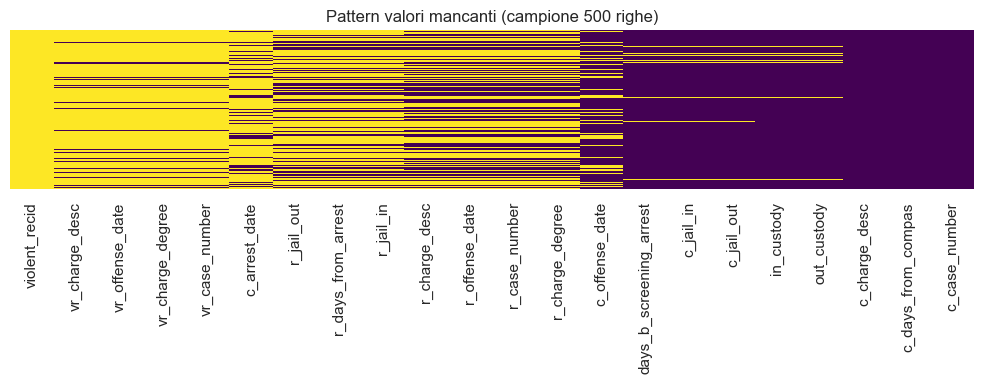

In [48]:
# Heatmap valori mancanti (campione per leggibilità)
print(missing)
if not missing.empty:
    sample = df[missing.index].sample(min(500, len(df)), random_state=42)
    plt.figure(figsize=(10, 4))
    sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title('Pattern valori mancanti (campione 500 righe)')
    plt.tight_layout()
    plt.show()

---
## 4. Analisi Distribuzione Features Numeriche

selezione delle variabili più rilevanti

In [49]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Colonne numeriche ({len(num_cols)}): {num_cols}')

Colonne numeriche (20): ['id', 'age', 'juv_fel_count', 'decile_score', 'juv_misd_count', 'juv_other_count', 'priors_count', 'days_b_screening_arrest', 'c_days_from_compas', 'is_recid', 'r_days_from_arrest', 'violent_recid', 'is_violent_recid', 'decile_score.1', 'v_decile_score', 'priors_count.1', 'start', 'end', 'event', 'two_year_recid']


istogrammi per feature numeriche

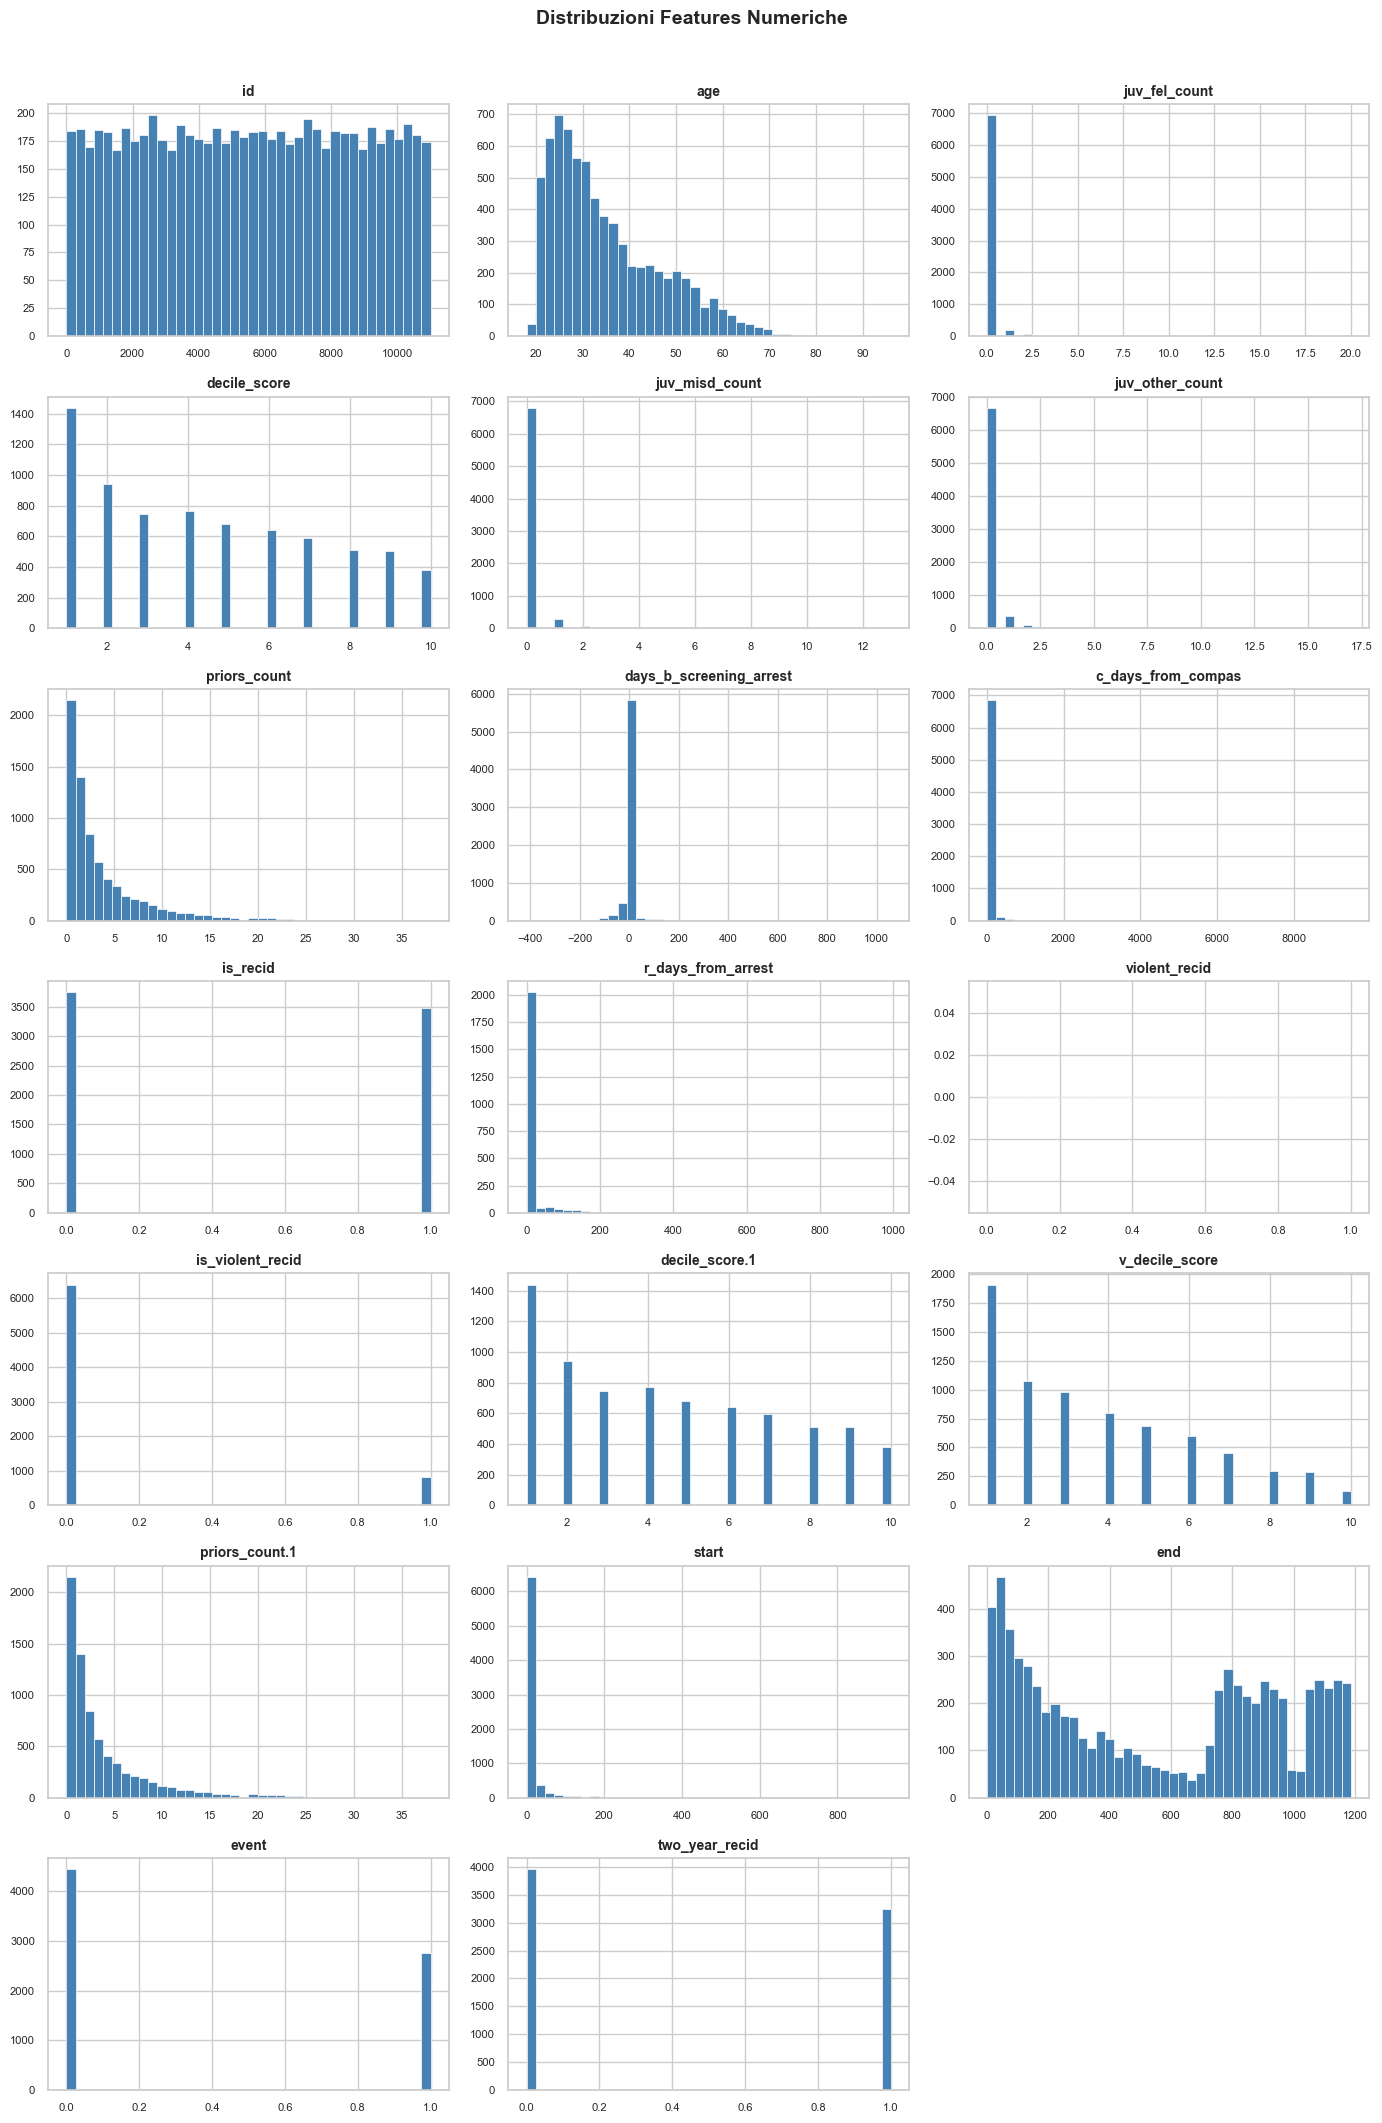

In [50]:
# Istogrammi per tutte le features numeriche
n = len(num_cols) # Numero di features numeriche
ncols = 3 # Numero di colonne per il layout
nrows = (n + ncols - 1) // ncols # Quante righe ci servono? Usiamo formula di arrotondamento per eccesso

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=8)

# Nascondi assi vuoti
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Distribuzioni Features Numeriche', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

boxplot per feature numeriche

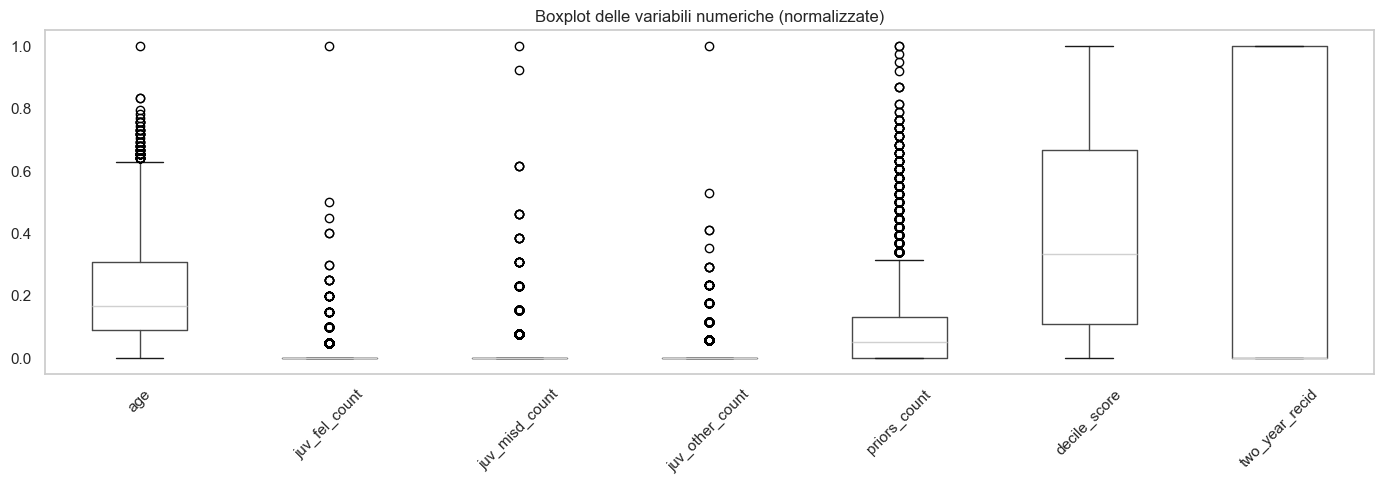

In [51]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

num_cols = [
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "decile_score",
    "two_year_recid"
]

df_num = df[num_cols].copy()

# opzionale: riempi NaN (anche se qui non dovrebbero esserci)
df_num = df_num.fillna(0)

# normalizzazione
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_num),
    columns=num_cols
)

# boxplot
plt.figure(figsize=(14, 5))
df_scaled.boxplot(rot=45, grid=False)
plt.title("Boxplot delle variabili numeriche (normalizzate)")
plt.tight_layout()
plt.show()

---
## 5. Analisi Features Categoriche

In [52]:
cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (33): ['name', 'first', 'last', 'compas_screening_date', 'sex', 'dob', 'age_cat', 'race', 'c_jail_in', 'c_jail_out', 'c_case_number', 'c_offense_date', 'c_arrest_date', 'c_charge_degree', 'c_charge_desc', 'r_case_number', 'r_charge_degree', 'r_offense_date', 'r_charge_desc', 'r_jail_in', 'r_jail_out', 'vr_case_number', 'vr_charge_degree', 'vr_offense_date', 'vr_charge_desc', 'type_of_assessment', 'score_text', 'screening_date', 'v_type_of_assessment', 'v_score_text', 'v_screening_date', 'in_custody', 'out_custody']


In [53]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
c_case_number,7192
name,7158
c_jail_in,6907
c_jail_out,6880
dob,5452
last,3950
r_case_number,3471
first,2800
out_custody,1169
in_custody,1156


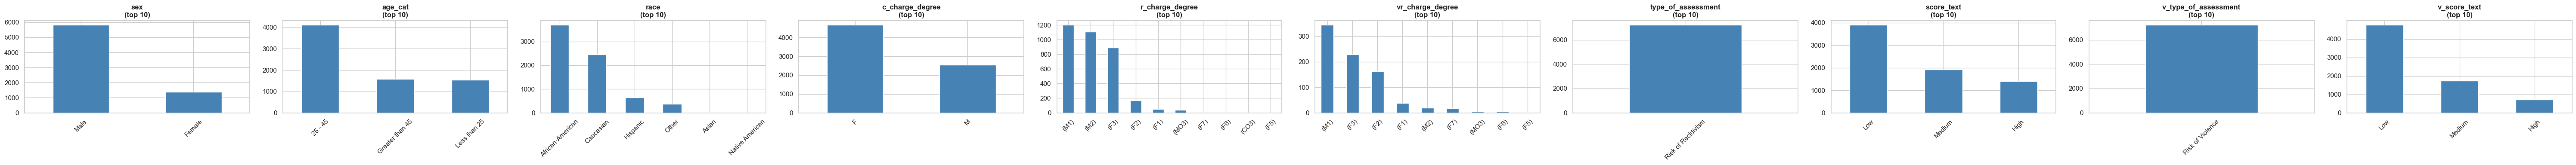

In [54]:
# Bar chart top-10 valori per colonne con cardinalità bassa-media (≤ 50 valori unici)
low_card = [c for c in cat_cols if df[c].nunique() <= 50]

if low_card:
    n = len(low_card)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 4))
    if n == 1:
        axes = [axes]
    
    for ax, col in zip(axes, low_card):
        counts = df[col].value_counts().head(10)
        counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(f'{col}\n(top 10)', fontweight='bold')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print('Tutte le colonne categoriche hanno alta cardinalità (> 50 valori).')

In [55]:
# Verifica duplicati esatti
n_dup = df.duplicated().sum()
print(f'Righe duplicate: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

Righe duplicate: 0 (0.00%)


---
## 6. Analisi Correlazioni

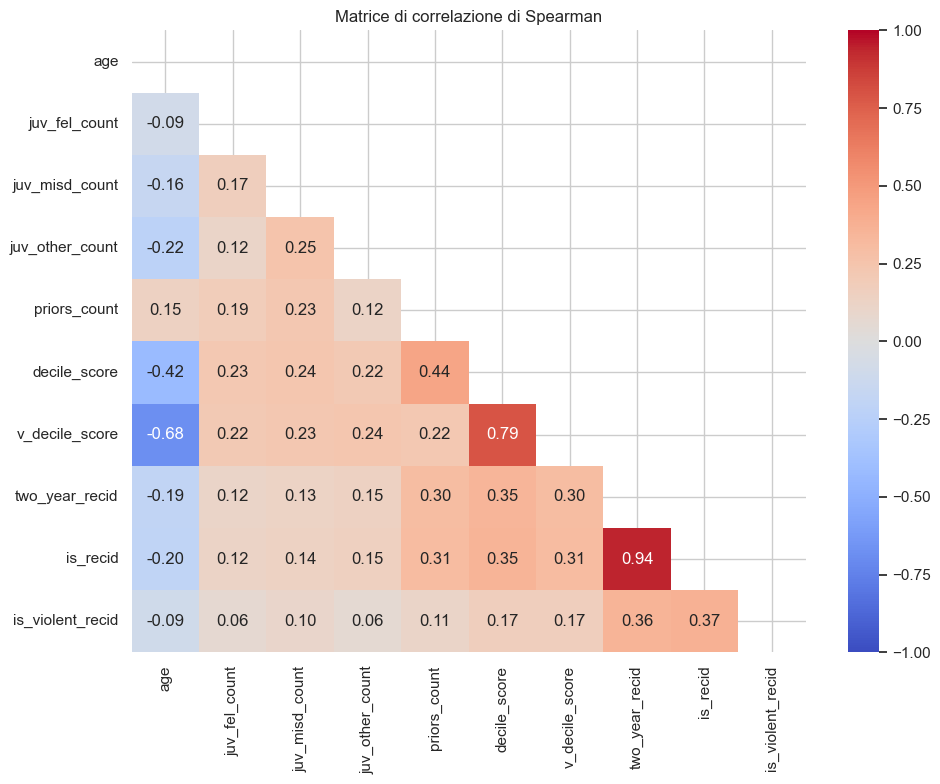

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

corr_cols = [
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "decile_score",
    "v_decile_score",
    "two_year_recid",
    "is_recid",
    "is_violent_recid"
]

corr_matrix = df[corr_cols].corr(method="spearman")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.title("Matrice di correlazione di Spearman")
plt.tight_layout()
plt.show()

In [57]:
# Top coppie più correlate (in valore assoluto)
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)
corr_pairs.columns = ['feature_1', 'feature_2', 'correlazione']
corr_pairs['abs_corr'] = corr_pairs['correlazione'].abs()
print('Top 10 coppie per correlazione assoluta:')
display(corr_pairs.sort_values('abs_corr', ascending=False).head(10).reset_index(drop=True))

Top 10 coppie per correlazione assoluta:


,feature_1,feature_2,correlazione,abs_corr
0,is_recid,two_year_recid,0.941,0.941
1,v_decile_score,decile_score,0.792,0.792
2,v_decile_score,age,-0.683,0.683
3,decile_score,priors_count,0.439,0.439
4,decile_score,age,-0.424,0.424
5,is_violent_recid,is_recid,0.372,0.372
6,is_violent_recid,two_year_recid,0.356,0.356
7,is_recid,decile_score,0.355,0.355
8,two_year_recid,decile_score,0.351,0.351
9,is_recid,priors_count,0.311,0.311


---
## 7. Rilevamento Outlier (metodo IQR)

In [58]:
def detect_outliers_iqr(df, cols, k=1.5):
    """Restituisce un DataFrame con conteggio e percentuale di outlier per ogni colonna."""
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({'colonna': col, 'lower_bound': lower, 'upper_bound': upper,
                        'n_outliers': n_out, 'pct_outliers': n_out / len(df) * 100})
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = detect_outliers_iqr(df, num_cols)
display(outlier_report.style.bar(subset=['pct_outliers'], color='#f4a261').format({'pct_outliers': '{:.2f}%'}))

,colonna,lower_bound,upper_bound,n_outliers,pct_outliers
3,juv_other_count,0.000000,0.000000,523,7.25%
4,priors_count,-7.500000,12.500000,455,6.31%
2,juv_misd_count,0.000000,0.000000,415,5.75%
1,juv_fel_count,0.000000,0.000000,282,3.91%
0,age,-0.500000,67.500000,61,0.85%
5,decile_score,-5.500000,14.500000,0,0.00%
6,two_year_recid,-1.500000,2.500000,0,0.00%


---
## 8. Rimozione duplicati

In [60]:
df_clean = df.copy()

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f'Duplicati rimossi: {before - after} righe  →  Shape: {df_clean.shape}')

Duplicati rimossi: 0 righe  →  Shape: (7214, 53)


### gestione valori mancanti

In [65]:
missing_clean = pd.DataFrame({
    'count': df_clean.isnull().sum(),
    'percent': df_clean.isnull().mean() * 100
}).query('count > 0').sort_values('percent', ascending=False)

if missing_clean.empty:
    print('Nessun valore mancante nel dataset selezionato!')
else:
    display(missing_clean)

,count,percent
days_b_screening_arrest,307,4.256


In [66]:
# Numeriche → imputa con mediana (robusta agli outlier)
# Categoriche → imputa con moda

for col in df_clean.select_dtypes(include='number').columns:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f'  [NUM] {col}: {n_miss} valori imputati con mediana ({median_val:.3f})')

for col in df_clean.select_dtypes(include=['object', 'string']).columns:
    n_miss = df_clean[col].isnull().sum()
    if n_miss > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f'  [CAT] {col}: {n_miss} valori imputati con moda ("{mode_val}")')

print(f'\nValori mancanti residui: {df_clean.isnull().sum().sum()}')

  [NUM] days_b_screening_arrest: 307 valori imputati con mediana (-1.000)

Valori mancanti residui: 0


In [67]:
print('=== NUMERICHE (dataset pulito) ===')
display(df_clean.describe().T)

print('=== CATEGORICHE (dataset pulito) ===')
display(df_clean.describe(include=['object']).T)

=== NUMERICHE (dataset pulito) ===


,count,mean,std,min,25%,50%,75%,max
age,7214.000,34.818,11.889,18.000,25.000,31.000,42.000,96.000
priors_count,7214.000,3.472,4.883,0.000,0.000,2.000,5.000,38.000
juv_fel_count,7214.000,0.067,0.474,0.000,0.000,0.000,0.000,20.000
juv_misd_count,7214.000,0.091,0.485,0.000,0.000,0.000,0.000,13.000
juv_other_count,7214.000,0.109,0.502,0.000,0.000,0.000,0.000,17.000
decile_score,7214.000,4.510,2.856,1.000,2.000,4.000,7.000,10.000
two_year_recid,7214.000,0.451,0.498,0.000,0.000,0.000,1.000,1.000
days_b_screening_arrest,7214.000,3.122,74.184,-414.000,-1.000,-1.000,-1.000,1057.000


=== CATEGORICHE (dataset pulito) ===


/var/folders/_r/144lp0vn6591pckkjz_5kll00000gn/T/ipykernel_21073/2103382676.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_clean.describe(include=['object']).T)


,count,unique,top,freq
age_cat,7214,3,25 - 45,4109
sex,7214,2,Male,5819
race,7214,6,African-American,3696
c_charge_degree,7214,2,F,4666
score_text,7214,3,Low,3897


In [68]:
print('=== RIEPILOGO PREPROCESSING ===')
print(f'  Shape originale  : {df.shape}')
print(f'  Shape finale     : {df_clean.shape}')
print(f'  Valori mancanti  : {df_clean.isnull().sum().sum()}')
print(f'  Tipi colonne     : {dict(df_clean.dtypes.value_counts())}')

df_clean.head()

=== RIEPILOGO PREPROCESSING ===
  Shape originale  : (7214, 53)
  Shape finale     : (7214, 13)
  Valori mancanti  : 0
  Tipi colonne     : {dtype('int64'): np.int64(7), <StringDtype(storage='python', na_value=nan)>: np.int64(5), dtype('float64'): np.int64(1)}


,age,age_cat,sex,race,priors_count,juv_fel_count,juv_misd_count,juv_other_count,c_charge_degree,decile_score,score_text,two_year_recid,days_b_screening_arrest
0,69,Greater than 45,Male,Other,0,0,0,0,F,1,Low,0,-1.000
1,34,25 - 45,Male,African-American,0,0,0,0,F,3,Low,1,-1.000
2,24,Less than 25,Male,African-American,4,0,0,1,F,4,Low,1,-1.000
3,23,Less than 25,Male,African-American,1,0,1,0,F,8,High,0,-1.000
4,43,25 - 45,Male,Other,2,0,0,0,F,1,Low,0,-1.000


In [69]:
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,7192.000,7214.000,2316.000,0.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000
mean,5501.256,34.818,0.067,4.510,0.091,0.109,3.472,3.305,57.731,0.481,20.269,NaN,0.114,4.510,3.692,3.472,11.465,553.437,0.383,0.451
std,3175.707,11.889,0.474,2.856,0.485,0.502,4.883,75.810,329.740,0.500,74.872,NaN,0.317,2.856,2.510,4.883,46.955,399.021,0.486,0.498
min,1.000,18.000,0.000,1.000,0.000,0.000,0.000,-414.000,0.000,0.000,-1.000,NaN,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000
25%,2735.250,25.000,0.000,2.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,NaN,0.000,2.000,1.000,0.000,0.000,148.250,0.000,0.000
50%,5509.500,31.000,0.000,4.000,0.000,0.000,2.000,-1.000,1.000,0.000,0.000,NaN,0.000,4.000,3.000,2.000,0.000,530.500,0.000,0.000
75%,8246.500,42.000,0.000,7.000,0.000,0.000,5.000,0.000,2.000,1.000,1.000,NaN,0.000,7.000,5.000,5.000,1.000,914.000,1.000,1.000
max,11001.000,96.000,20.000,10.000,13.000,17.000,38.000,1057.000,9485.000,1.000,993.000,NaN,1.000,10.000,10.000,38.000,937.000,1186.000,1.000,1.000
